# 5. POŁĄCZENIA RESIDUALNE I TRANSFER LEARNING

## 0.Cel listy

Celem tej listy zadań jest zapoznanie się z:

* gotowymi architekturami sieci neuronowych,
* ideą **połączeń residualnych (skip connections)**,
* oraz praktycznym wykorzystaniem **transfer learningu** w zadaniach z zakresu wizji komputerowej.

W poprzednich listach budowaliśmy sieci neuronowe „od zera”, projektując architekturę warstwa po warstwie. W praktyce jednak **bardzo rzadko trenuje się modele od podstaw**- zamiast tego korzysta się z gotowych, sprawdzonych architektur i wag wytrenowanych na dużych zbiorach danych, dotrenowując model pod konretne zadanie.



W tej liście:

* skupimy się na architekturach z rodziny **ResNet**,
* zobaczymy, czym są i po co stosuje się połączenia residualne,
* porównamy różne strategie treningu:

  * inferencję na modelu pretrenowanym,
  * trenowanie tylko ostatniej warstwy,
  * fine-tuning całego modelu,
  * trening od zera.



Do wykonania zadania rekomendowane jest użycie zbioru **CIFAR** z torchvision z powodu, że jest to trudniejszy zbiór i powinno być na nim lepiej widać, różne schematy uczenia, ale jeśli będzie występowal problem z zasobami obliczeniowymi można wykonać zadanie na zbiorze **FashionMNIST**




## 1.Połączenia residualne- teoria

### Problem zanikającego i wybuchającego gradientu

Podczas trenowania sieci neuronowej używamy algorytmu **propagacji wstecznej (backpropagation)**, w którym gradient funkcji straty jest przekazywany od wyjścia sieci do jej początkowych warstw.

Dla bardzo głębokich sieci pojawiają się dwa poważne problemy:

###  Zanikający gradient (vanishing gradient)

* gradient w kolejnych warstwach staje się coraz mniejszy,
* pierwsze warstwy uczą się bardzo wolno lub wcale,
* sieć nie wykorzystuje swojej głębokości.

###  Wybuchający gradient (exploding gradient)

* gradient w kolejnych warstwach gwałtownie rośnie,
* prowadzi to do niestabilnego treningu,
* wagi mogą przyjmować bardzo duże wartości (NaN).

Oba problemy są szczególnie widoczne w **głębokich sieciach** (dziesiątki lub setki warstw).



## Skąd bierze się ten problem? (intuicyczna matematyka)

Rozważmy bardzo uproszczony przypadek sieci składającej się z wielu warstw:

$$
h_l = f(W_l h_{l-1})
$$


Podczas propagacji wstecznej gradient względem wcześniejszych warstw zawiera **iloczyn pochodnych**:

$$
\frac{\partial L}{\partial h_0}
$$

$$
\frac{\partial L}{\partial h_L}
\cdot
\prod_{l=1}^{L}
\frac{\partial h_l}{\partial h_{l-1}}
$$

Jeśli:

* pochodne są **mniejsze od 1** - iloczyn dąży do zera → *zanik gradientu*
* pochodne są **większe od 1** - iloczyn rośnie wykładniczo → *wybuch gradientu*

Nawet przy użyciu funkcji aktywacji takich jak ReLU oraz technik typu Batch Normalization, problem **nie znika całkowicie** dla bardzo głębokich sieci.

#### Dodatkowe materiały:
- [Vanishing AND Exploding Gradient Problem Explained](https://www.youtube.com/watch?v=CzNFuL_5uig)
- [kod + wizaulizacje problemu](https://www.geeksforgeeks.org/deep-learning/vanishing-and-exploding-gradients-problems-in-deep-learning/)




### Intuicja stojąca za połączeniem residualnym

Zastanówmy się nad prostym przypadkiem.

Załóżmy, że idealna transformacja pomiędzy wejściem a wyjściem pewnej części sieci to:
$$
H(x) = x
$$

Czyli: **warstwy nic nie zmieniają**.

Dla klasycznej sieci neuronowej oznacza to, że musi ona nauczyć się funkcji identyczności, co w praktyce **nie jest trywialne** dla wielu warstw nieliniowych.



Zamiast uczyć się funkcji:
$$
H(x)
$$

możemy uczyć się **residuum**:
$$
F(x) = H(x) - x
$$

Jeśli najlepszym rozwiązaniem jest identyczność, to:
$$
F(x) = 0
$$

Uczenie się „zera” lub „małej poprawki” jest:

* łatwiejsze,
* stabilniejsze,
* szybsze dla optymalizacji gradientowej.



### Wzór matematyczny połączenia residualnego

Połączenie residualne definiujemy jako:

$$
y = F(x) + x
$$

gdzie:

* x - wejście do bloku,
* F(x) - klasyczna transformacja (np. Conv -> ReLU -> Conv),
* y - wyjście bloku residualnego.

### Co to zmienia?

* gradient może przepływać **bezpośrednio** przez składnik (+x),
* nawet jeśli F(x) jest trudne do nauczenia,
* sieć zawsze ma „bezpieczną ścieżkę” dla propagacji gradientu.


## Najważniejsze konsekwencje połączeń residualnych

* umożliwiają trenowanie **bardzo głębokich sieci**,
* zmniejszają problem degradacji jakości,
* stabilizują propagację gradientu,
* sprawiają, że dodawanie kolejnych warstw **nie pogarsza wyników**.

Poniżej obrazek przedstawiający schemat działania tego połączenia.


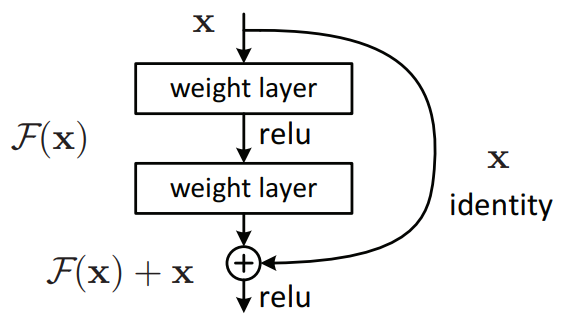

DODATKOWE MATERIAŁY:
- [ORGINALNY PAPER](https://arxiv.org/pdf/1512.03385) - Gorąco polecam, ponieważ autorzy bardzo klarownie postawili hipotezę, ekperyment weryfikujący, oraz wnioski. Jest to wzór pod względem tego jak publikacja powinna wyglądać.
- [ORGINALNY PAPER OMÓWIENIE NA YT](https://www.youtube.com/watch?v=GWt6Fu05voI)
- [SZCZEGÓŁOWE WYJAŚNIENIE](https://mbrenndoerfer.com/writing/residual-connections-deep-neural-networks-resnet)

## 2. ZADANIE 1. IMPLEMENTACJA MODUŁU RESIDUALNEGO
Jako zadanie rozgrzewkowe należy na podstawie schematu powyżej dokończyć implementację modułu residualnego, przepuścić przez niego "dummy input" i uruchomić testy w celu weryfikacji poprawności. Celem jest zobaczenie przykładowej implementacji takiego bloku.

**UWAGA**: Symbol "+" na schemacie odpowada zwykłemu **dodaniu tensorów** a nie konkatenacji.

In [ ]:
#Dummy wejście (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

import torch
# Ustalmy powtarzalność
torch.manual_seed(0)

# Dummy batch obrazów: (batch_size, channels, height, width)
B, C, H, W = 4, 16, 32, 32
x = torch.randn(B, C, H, W)
print("x shape:", x.shape)


x shape: torch.Size([4, 16, 32, 32])


In [ ]:
# Moduł ResidualBlock z brakującym kodem (TODO)

import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    Blok residualny zgodny ze schematem:
        x -> Conv -> ReLU -> Conv -> ( + x ) -> ReLU
    Zakładamy, że wejście i wyjście mają te same wymiary (C, H, W).
    """
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        padding = kernel_size // 2  # żeby zachować H,W dla kernel=3

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO 1: policz F(x) = Conv -> ReLU -> Conv
        # TODO 2: dodaj skip connection: out = F(x) + x
        # TODO 3: zastosuj ReLU na końcu i zwróć wynik

        # ----- START TODO -----
        fx = self.conv1(x)
        fx = self.relu(fx)
        fx = self.conv2(fx)
        out = fx + x
        out = self.relu(out)
        return out
        # ----- END TODO -----


In [ ]:
# Testy (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

def zero_out_conv(conv: nn.Conv2d):
    with torch.no_grad():
        conv.weight.zero_()
        if conv.bias is not None:
            conv.bias.zero_()

# 1) Inicjalizacja i test wymiarów
block = ResidualBlock(channels=C)

y = block(x)
print("y shape:", y.shape)

assert y.shape == x.shape, f"Shape mismatch: got {y.shape}, expected {x.shape}"
print("Shape test passed")

# 2) Test semantyczny: jeśli ustawimy wagi obu conv na 0 -> F(x)=0
#    wtedy y = ReLU(x) (bo na końcu jest ReLU po dodaniu).
zero_out_conv(block.conv1)
zero_out_conv(block.conv2)

y2 = block(x)
expected = torch.relu(x)

max_diff = (y2 - expected).abs().max().item()
print("max |y2 - ReLU(x)| =", max_diff)

assert torch.allclose(y2, expected, atol=1e-6), "Residual behavior test failed"
print("Residual behavior test passed (F(x)=0 => y=ReLU(x))")

# 3) Test gradientu: sprawdzamy czy gradient przepływa do x
x_req = x.clone().detach().requires_grad_(True)
y3 = block(x_req)
loss = y3.sum()
loss.backward()

grad_norm = x_req.grad.norm().item()
print("x grad norm:", grad_norm)

assert grad_norm > 0, "Gradient flow test failed (grad_norm should be > 0)"
print("Gradient flow test passed")


y shape: torch.Size([4, 16, 32, 32])
Shape test passed
max |y2 - ReLU(x)| = 0.0
Residual behavior test passed (F(x)=0 => y=ReLU(x))
x grad norm: 180.78993225097656
Gradient flow test passed


## 3. PRETRENOWANE MODELE I TRANSFER LEARNING


#### Dlaczego nie zawsze trenujemy model od zera?

W zadaniach z zakresu wizji komputerowej obrazy- niezależnie od konkretnego problemu- mają **wspólną strukturę**.

W głębokich sieciach konwolucyjnych:

* **początkowe warstwy** uczą się bardzo ogólnych cech:

  * krawędzie,
  * narożniki,
  * proste tekstury,
* **środkowe warstwy** łączą je w bardziej złożone wzorce:

  * fragmenty obiektów,
  * charakterystyczne kształty,
* **końcowe warstwy** są najbardziej specyficzne dla zadania:

  * konkretne klasy,
  * decyzje klasyfikacyjne.

Oznacza to, że wiedza zdobyta przez model na jednym zadaniu (np. klasyfikacja milionów obrazów) może być **ponownie wykorzystana** w innym, podobnym zadaniu.

Dlatego w praktyce:

* **nie musimy uczyć modelu wszystkiego od zera**,
* możemy wykorzystać wcześniej wyuczone wagi,
* oszczędzamy czas, dane i zasoby obliczeniowe.


DODATKOWE MATERIAŁY:
- [Co "widzą" CNN-y w kolejnych warstwach](https://arxiv.org/pdf/1311.2901)


## Podstawowe pojęcia: pretraining i transfer learning

**Model pretrenowany (pretrained model)**

* jego wagi zostały wyuczone na dużym zbiorze danych,
* zwykle na **ogólnym zadaniu** (np. klasyfikacja obrazów w przypadku computer vision, chodź nie musi tak być),
* Często mówi się o takim modelu w naszym rozwiązaniu jako **Backbone**, ponieważ on odpowada za większość "wiedzy" w naszym modelu.

W przypadku wizji komputerowej bardzo często modele są pretrenowane na zbiorze ImageNet, który zawiera miliony obrazów i tysiące klas.

Przykład:
Resnet18 z biblioteki torchvision wraz z wagami z ImageNeta.



**Zamrażanie wag**
- Polega na tym że część lub całość modelu (wag) nie przekazuje gradientu dalej, co oznacza że te konretne wagi nie będą się dalej optymalizowały w trakcie trenigu
- W torchu odbywa się między innymi poprzez
  * `requires_grad = False`,
- Stosowane kiedy chcemy pozostawić wagi modelu i zmodyfikować tylko jego fragment (najczęściej ostatnią warstwę klasyfikujacą lub pare ostatnich warst)


**Transfer learning**
Polega na wykorzystaniu modelu pretrenowanego oraz dostosowaniu go do **zadania docelowego**.

Może to przyjmować różne formy, w zależności od ilości danych i podobieństwa zadań. Jest to szeroki temat, ale najkrócej tłumacząc strategie jakie są nabardziej znane to:
- **linear probing**- Zamrożenie całości modelu i wytrenowaniu jedynie ostatniej warstwy klasyfikującej pod nasze zadanie .
- **partial fine-tuning**Zamrożenie większości modelu, ale dotrenowujemy też ostatnie warstwy/blocki w naszym backbonie . Ile dokładnie odmrażamy a ile zostawiamy jest bardzo mocno zależne od naszego zadania, ilości danych  oraz doświadczenia.
- **Full fine-tuning** Odmrożenie całego modelu i dotrenowanie go w całości naszych danych


DODATKOWE MATERIAŁY:
- [linear probing vs finetuning](https://www.phontron.com/class/anlp2022/assets/slides/anlp-10-raghunathan.pdf)
- [how to freez model in torch](https://python.plainenglish.io/how-to-freeze-model-weights-in-pytorch-for-transfer-learning-step-by-step-tutorial-a533a58051ef)



## Architektura ResNet i modele dostępne w torchvision

**ResNet (Residual Network)** to rodzina głębokich sieci konwolucyjnych opartych na:

* blokach residualnych,
* połączeniach typu skip connection,
* bardzo dużej głębokości (dziesiątki lub setki warstw).

Kluczowa idea:

* sieć uczy się **residuum** zamiast pełnej transformacji,
* co umożliwia stabilny trening bardzo głębokich modeli.


Biblioteka `torchvision.models` udostępnia gotowe implementacje ResNetów, m.in.:

* `resnet18`
* `resnet34`
* `resnet50`
* `resnet101`
* `resnet152`

Różnią się one:

* liczbą warstw,
* liczbą parametrów,
* złożonością bloków residualnych.

Modele te:

* mogą być inicjalizowane losowo,
* lub z wagami **pretrenowanymi na ImageNet**.


DODATKOWE MATERIAŁY:
- [torchvision resnet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

## 4. ZADANIE 2- transfer learning



Celem zadania jest praktyczne zapoznanie się z różnymi strategiami wykorzystania **modeli pretrenowanych** na przykładzie architektury **ResNet** oraz porównanie ich zachowania podczas treningu.


### 1. Wybór i analiza architektury

1. Wybierz **jeden model z rodziny ResNet**:

   * `ResNet18` lub `ResNet34`
     (większe modele nie są wymagane do tego zadania).

2. Załaduj model **z wagami pretrenowanymi na ImageNet**.

3. Wyświetl architekturę modelu (`print(model)` lub podobnie) i:

   * zidentyfikuj część konwolucyjną (backbone),
   * zlokalizuj ostatnią warstwę klasyfikacyjną,
   * zwróć uwagę na strukturę bloków residualnych.

Celem tego punktu jest **zrozumienie, z jakich elementów składa się model**, a nie tylko jego użycie jako „czarnej skrzynki”.


### 2. Przygotowanie danych i wyjścia modelu

1. Wykorzystaj zbiór danych wskazany we wprowadzeniu (np. CIFAR / FashionMNIST).
2. Dostosuj dane wejściowe do wymagań modelu:

   * odpowiedni rozmiar obrazu,
   * liczba kanałów,
   * normalizacja.

3. Zastąp **ostatnią warstwę liniową** modelu tak, aby liczba neuronów wyjściowych odpowiadała liczbie klas w zadaniu docelowym.


### 3. Zestaw eksperymentów

Na tym samym zbiorze danych przeprowadź **następujące eksperymenty**, zachowując spójne ustawienia (batch size, optimizer, itp.).

- Eksperyment 1 - Linear probing

  * Zamroź wszystkie warstwy modelu poza ostatnią warstwą liniową.
  * Trenuj **tylko nową warstwę klasyfikacyjną**.
  * Model pełni rolę ekstraktora cech.


- Eksperyment 2 - Partial fine-tuning

  * Zamroź większość modelu,
  * Odmroź:

    * ostatni blok ResNeta,
    * oraz warstwę klasyfikacyjną.
  * Trenuj tylko te elementy.


- Eksperyment 3 - Full fine-tuning

  * Użyj modelu pretrenowanego,
  * Odmroź **wszystkie warstwy**,
  * Dotrenuj cały model na zadaniu docelowym.
  * Trening **nie musi być długi** - wystarczy kilka lub kilkanaście epok.


- Eksperyment 4 - Trening od zera

  * Załaduj ten sam model ResNet, ale **bez wag pretrenowanych**.
  * Wytrenuj go od zera na tym samym zbiorze danych.
  * Wystarczy kilka pierwszych epok - celem jest obserwacja przebiegu uczenia.


### UWAGI

* Stosuj dobre praktyki treningowe z poprzednich list.
* **Zawsze śledź `train loss` oraz `validation loss`** - w tym zadaniu jest to szczególnie istotne.
* Monitoruj metryki na zbiorze treningowym, walidacyjnym i testowym.
* Porównuj podejścia między sobą:

  * wartości strat,
  * metryki walidacyjne i testowe,
  * szybkość oraz stabilność zbieżności.
* Zwróć uwagę na różnice w przebiegu krzywych uczenia między ekperymentami.
* Przy full fine-tuningu i treningu od zera **wystarczy kilka / kilkanaście epok** - nie jest wymagane doprowadzenie treningu do pełnej konwergencji.
* Celem zadania jest **zrozumienie dynamiki uczenia i wpływu pretrenowania**, a nie maksymalizacja końcowej dokładności.
* Przy dotrenowywaniu, często stosuje się mniejszy lr niż przy treningu od zera.


In [ ]:
# TODO- WPISZ SWÓJ KOD

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

class TrainerTorch:
    def __init__(self,
                 model,
                 n_epochs=20,
                 batch_size=128,
                 lr=0.01,
                 patience=3,
                 optimizer: str = "SGD",
                 use_early_stopping: bool = False,
                 generator=None,
                 regularization: bool = False,
                 lambda_reg=0.01,
                 cosine_learning_rate: bool = False):

        self.model = model
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.optimizer_name = optimizer
        self.use_early_stopping = use_early_stopping
        self.generator = generator
        self.regularization = regularization
        self.cosine_learning_rate = cosine_learning_rate
        self.lambda_reg = lambda_reg

        self.lr_history = defaultdict(list)

        self.history = defaultdict(list)
        self.best_val_loss = float('inf')
        self.early_stop_counter = 0

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.criterion = nn.CrossEntropyLoss()

    def train(self, train_dataset, val_dataset):

        train_loader = DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            generator=self.generator,
            num_workers=2,
            pin_memory=True
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        print(f"Rozpoczynam trening na: {self.device}")

        weight_decay = self.lambda_reg if self.regularization else 0.0

        if self.optimizer_name == "SGD":
            optimizer = torch.optim.SGD(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr, weight_decay=weight_decay)

        if self.cosine_learning_rate:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.n_epochs)

        for epoch in range(self.n_epochs):
            self.model.train()

            epoch_loss = 0.0
            epoch_correct = 0
            total_samples = 0 #zeby nie leciec przez caly zbior potem w evaluate (20 epok zajelo 8min)

            for X, y in train_loader:
                X, y = X.to(self.device), y.to(self.device)

                optimizer.zero_grad()
                output = self.model(X)
                loss = self.criterion(output, y)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item() * X.size(0)
                predicted = output.argmax(dim=1)
                epoch_correct += (predicted == y).sum().item()
                total_samples += y.size(0)

            if self.cosine_learning_rate:
                scheduler.step()
                print(scheduler.get_lr())
                self.lr_history['lr'].append(scheduler.get_last_lr())

            train_l = epoch_loss / total_samples
            train_acc = epoch_correct / total_samples

            self.model.eval()
            with torch.no_grad():
                val_l, val_acc, _ = self.evaluate(val_loader)

                self.history['train_loss'].append(train_l)
                self.history['val_loss'].append(val_l)
                self.history['train_acc'].append(train_acc)
                self.history['val_acc'].append(val_acc)

                print(f"Epoch {epoch+1}/{self.n_epochs} | Train Loss: {train_l:.4f} | Val Loss: {val_l:.4f} | Val Acc: {val_acc:.4f}")

                if val_l < self.best_val_loss:
                    self.best_val_loss = val_l
                    self.early_stop_counter = 0
                    torch.save({
                        'epoch': epoch,
                        'model_state_dict': self.model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'loss': val_l,
                    }, 'checkpoint.pt')
                else:
                    self.early_stop_counter += 1

                if self.use_early_stopping and self.early_stop_counter >= self.patience:
                    print(f"Early stopping at epoch {epoch+1}")
                    break

        self.plot_history()
        checkpoint = torch.load('checkpoint.pt', weights_only=False)
        self.model.load_state_dict(checkpoint['model_state_dict'])

    def evaluate(self, loader):
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        all_preds = []

        self.model.eval()
        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)

                output = self.model(X)
                loss = self.criterion(output, y)


                total_loss += loss.item() * X.size(0)

                predicted = output.argmax(dim=1)
                total_correct += (predicted == y).sum().item()

                total_samples += y.size(0)
                all_preds.append(output)

        avg_loss = total_loss / total_samples
        avg_acc = total_correct / total_samples
        full_preds = torch.cat(all_preds) if all_preds else None

        return avg_loss, avg_acc, full_preds


    def predict(self, x_test):
        test_loader = DataLoader(
            x_test,
            batch_size=self.batch_size,
            shuffle=False,
            generator=self.generator
        )
        self.model.eval()
        with torch.no_grad():
          loss, acc, A = self.evaluate(test_loader)
          print("Loss: "+str(loss))
          print("Acc: "+str(acc))
          return A


    def plot_history(self):
      epochs = range(1, len(self.history['train_loss']) + 1)

      plt.figure(figsize=(16, 5))

      plt.subplot(1, 2, 1)
      plt.plot(epochs, self.history['train_loss'], label='Train Loss')
      plt.plot(epochs, self.history['val_loss'], label='Val Loss')
      plt.title('Training and Validation Loss')
      plt.xlabel('Epochs')
      plt.ylabel('Loss')
      plt.legend()
      plt.grid(True)

      plt.subplot(1, 2, 2)
      plt.plot(epochs, self.history['train_acc'], label='Train Acc')
      plt.plot(epochs, self.history['val_acc'], label='Val Acc')
      plt.title('Training and Validation Accuracy')
      plt.xlabel('Epochs')
      plt.ylabel('Accuracy')
      plt.legend()
      plt.grid(True)

      plt.tight_layout()
      plt.show()

In [ ]:
import torchvision.models as models

resnet18_e1 = models.resnet18(weights='DEFAULT')

print(resnet18_e1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

zidentyfikuj część konwolucyjną (backbone),
zlokalizuj ostatnią warstwę klasyfikacyjną,
zwróć uwagę na strukturę bloków residualnych.

 (fc): Linear(in_features=512, out_features=1000, bias=True) - część klasyfikacyjna


 4 layery części konwolucyjnej z:  
  (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)

(bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     
     
 (relu): ReLU(inplace=True)

In [ ]:
from pathlib import Path
from google.colab import drive
from torchvision import datasets, transforms

drive.mount('/content/drive')
base_path = Path('/content/drive/MyDrive/CIFAR')

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


trainset = datasets.CIFAR10(
    root=base_path,
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root=base_path,
    train=False,
    download=True,
    transform=transform
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
customSEED=42

import torch
from torch.utils.data import DataLoader, random_split



np.random.seed(customSEED)
torch.manual_seed(customSEED)
torch.cuda.manual_seed_all(customSEED)

g = torch.Generator()
g.manual_seed(customSEED)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_subset, val_subset = random_split(trainset, [train_size, val_size], generator=g)


- Eksperyment 1 - Linear probing

  * Zamroź wszystkie warstwy modelu poza ostatnią warstwą liniową.
  * Trenuj **tylko nową warstwę klasyfikacyjną**.
  * Model pełni rolę ekstraktora cech.

Niestety tylko 5 epok, bo model jest dosyć ciężki

Rozpoczynam trening na: cuda
[0.000978266982572228]


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1427: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Epoch 1/15 | Train Loss: 0.9612 | Val Loss: 0.6733 | Val Acc: 0.7751
[0.0009255265423839751]
Epoch 2/15 | Train Loss: 0.6462 | Val Loss: 0.6093 | Val Acc: 0.7880
[0.0008550992276841412]
Epoch 3/15 | Train Loss: 0.6007 | Val Loss: 0.5816 | Val Acc: 0.7990
[0.0007700306270606676]
Epoch 4/15 | Train Loss: 0.5799 | Val Loss: 0.5684 | Val Acc: 0.8000
[0.0006740035774996317]
Epoch 5/15 | Train Loss: 0.5637 | Val Loss: 0.5577 | Val Acc: 0.8066
[0.0005711751638541405]
Epoch 6/15 | Train Loss: 0.5544 | Val Loss: 0.5502 | Val Acc: 0.8078
[0.00046599208849497923]
Epoch 7/15 | Train Loss: 0.5447 | Val Loss: 0.5453 | Val Acc: 0.8107
[0.00036299167462173343]
Epoch 8/15 | Train Loss: 0.5398 | Val Loss: 0.5454 | Val Acc: 0.8102
[0.00026659558371051943]
Epoch 9/15 | Train Loss: 0.5334 | Val Loss: 0.5482 | Val Acc: 0.8077
[0.00018090169943749487]
Epoch 10/15 | Train Loss: 0.5298 | Val Loss: 0.5350 | Val Acc: 0.8139
[0.00010947455564845698]
Epoch 11/15 | Train Loss: 0.5243 | Val Loss: 0.5355 | Val Acc: 0

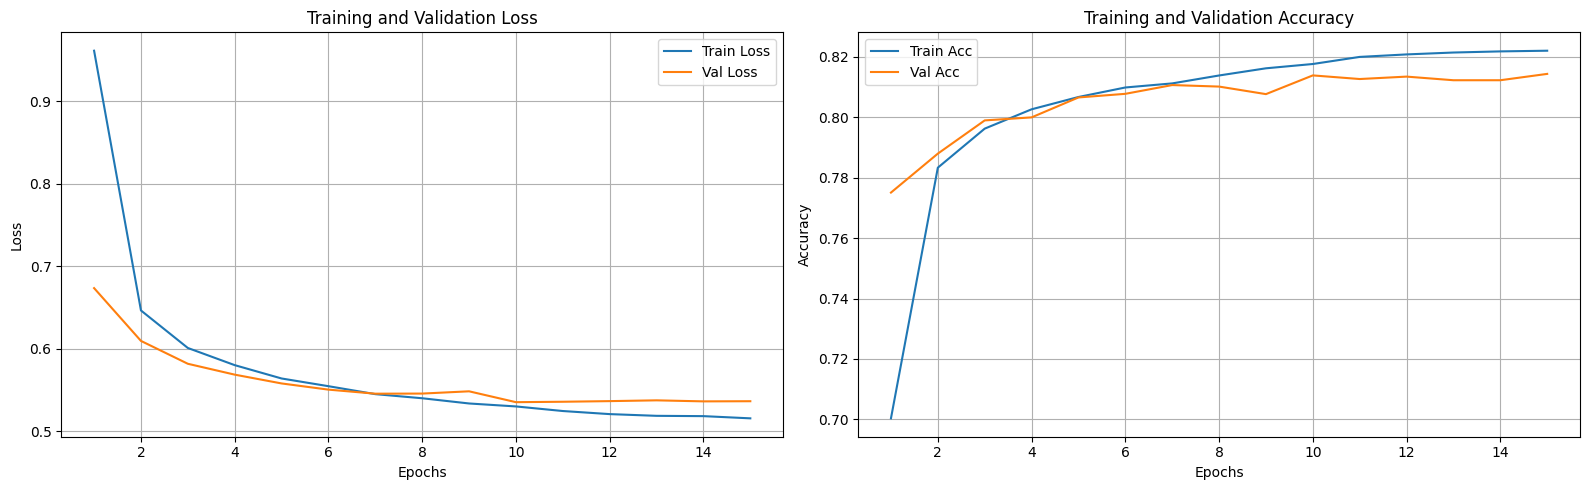

Loss: 0.560653666973114
Acc: 0.8092


tensor([[-4.8202, -5.4320, -3.4037,  ..., -5.5793, -5.7884, -5.6402],
        [ 0.5503, -0.7877, -1.7868,  ..., -3.7176,  4.0910, -7.1516],
        [-1.2333, -3.6001, -5.2940,  ..., -4.6990,  4.4371, -0.5010],
        ...,
        [-3.5579, -5.6837, -0.9165,  ..., -2.6298, -3.5069, -4.2760],
        [-0.7897,  0.6014, -1.6234,  ..., -2.4191, -3.7829, -4.7836],
        [-4.7268, -5.0229, -5.4005,  ...,  7.1379, -8.4544, -7.0101]],
       device='cuda:0')

In [ ]:
for param in resnet18_e1.parameters():
    param.requires_grad = False

num_ftrs = resnet18_e1.fc.in_features

resnet18_e1.fc = nn.Linear(num_ftrs, 10)

trainer = TrainerTorch(model=resnet18_e1, n_epochs=15, lr=0.001, optimizer="Adam", cosine_learning_rate=True, regularization=True, lambda_reg=1e-4)

trainer.train(train_subset, val_subset)

trainer.predict(testset)

Zamroź większość modelu,

Odmroź:

ostatni blok ResNeta,
oraz warstwę klasyfikacyjną.
Trenuj tylko te elementy.

Rozpoczynam trening na: cuda
[0.000978266982572228]
Epoch 1/15 | Train Loss: 0.4320 | Val Loss: 0.3416 | Val Acc: 0.8793
[0.0009255265423839751]
Epoch 2/15 | Train Loss: 0.1953 | Val Loss: 0.4246 | Val Acc: 0.8649
[0.0008550992276841412]
Epoch 3/15 | Train Loss: 0.1090 | Val Loss: 0.3375 | Val Acc: 0.8940
[0.0007700306270606676]
Epoch 4/15 | Train Loss: 0.0748 | Val Loss: 0.3732 | Val Acc: 0.8966
[0.0006740035774996317]
Epoch 5/15 | Train Loss: 0.0469 | Val Loss: 0.3520 | Val Acc: 0.9011
[0.0005711751638541405]
Epoch 6/15 | Train Loss: 0.0388 | Val Loss: 0.4313 | Val Acc: 0.8902
[0.00046599208849497923]
Epoch 7/15 | Train Loss: 0.0217 | Val Loss: 0.3253 | Val Acc: 0.9115
[0.00036299167462173343]
Epoch 8/15 | Train Loss: 0.0155 | Val Loss: 0.3529 | Val Acc: 0.9062
[0.00026659558371051943]
Epoch 9/15 | Train Loss: 0.0076 | Val Loss: 0.3693 | Val Acc: 0.9075
[0.00018090169943749487]
Epoch 10/15 | Train Loss: 0.0049 | Val Loss: 0.2995 | Val Acc: 0.9198
[0.00010947455564845698]
Epoch 11/15 

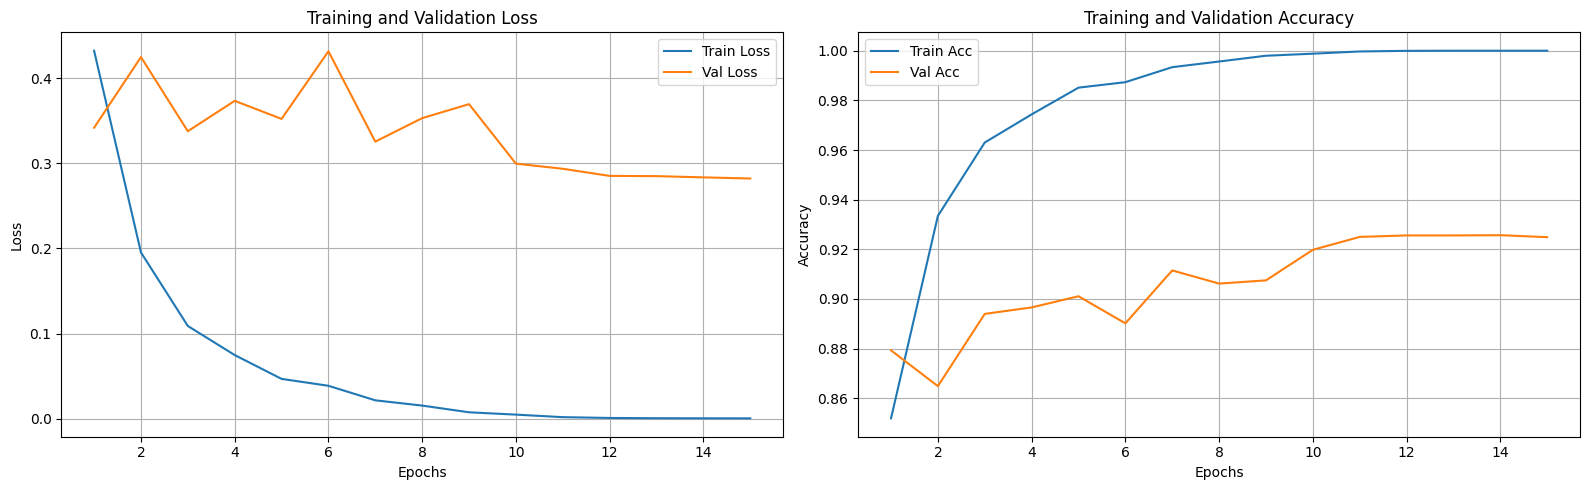

Loss: 0.3339317745447159
Acc: 0.9171


tensor([[-4.7396, -5.8625, -6.5882,  ..., -7.2912, -7.1341, -8.5987],
        [ 0.2238, -1.8940, -3.8458,  ..., -4.6815,  8.0570, -5.4578],
        [-2.9401,  2.5855, -4.9939,  ..., -4.2274,  4.6647, -1.6343],
        ...,
        [-7.9640, -4.7519, -2.7243,  ..., -4.2849, -5.5207, -5.3547],
        [-4.3535,  7.2269, -2.3764,  ..., -3.4857, -5.8056, -3.3485],
        [-5.3436, -3.6666, -5.1708,  ..., 10.5565, -4.7412, -3.6165]],
       device='cuda:0')

In [ ]:
resnet18_e2 = models.resnet18(weights='DEFAULT')


for param in resnet18_e2.parameters():
    param.requires_grad = False

for param in resnet18_e2.layer4.parameters():
    param.requires_grad = True


resnet18_e2.fc.requires_grad = True
num_ftrs = resnet18_e2.fc.in_features
resnet18_e2.fc = nn.Linear(num_ftrs, 10)

trainer = TrainerTorch(model=resnet18_e2, n_epochs=15, lr=0.001, optimizer="Adam", cosine_learning_rate=True, regularization=True, lambda_reg=1e-4)

trainer.train(train_subset, val_subset)

trainer.predict(testset)

- Eksperyment 3 - Full fine-tuning

  * Użyj modelu pretrenowanego,
  * Odmroź **wszystkie warstwy**,
  * Dotrenuj cały model na zadaniu docelowym.
  * Trening **nie musi być długi** - wystarczy kilka lub kilkanaście epok.


Rozpoczynam trening na: cuda
[9.516553824444453e-05]


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1427: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Epoch 1/10 | Train Loss: 0.3935 | Val Loss: 0.2006 | Val Acc: 0.9331
[8.386590697412431e-05]
Epoch 2/10 | Train Loss: 0.0958 | Val Loss: 0.1819 | Val Acc: 0.9374
[6.968044012954537e-05]
Epoch 3/10 | Train Loss: 0.0242 | Val Loss: 0.1544 | Val Acc: 0.9499
[5.3959611008113404e-05]
Epoch 4/10 | Train Loss: 0.0080 | Val Loss: 0.1598 | Val Acc: 0.9516
[3.819660112501051e-05]
Epoch 5/10 | Train Loss: 0.0034 | Val Loss: 0.1444 | Val Acc: 0.9560
[2.3872875703131575e-05]
Epoch 6/10 | Train Loss: 0.0019 | Val Loss: 0.1466 | Val Acc: 0.9564
[1.2295598939793906e-05]
Epoch 7/10 | Train Loss: 0.0015 | Val Loss: 0.1432 | Val Acc: 0.9568
[4.424211972088168e-06]
Epoch 8/10 | Train Loss: 0.0012 | Val Loss: 0.1449 | Val Acc: 0.9558
[6.271407734229156e-07]
Epoch 9/10 | Train Loss: 0.0011 | Val Loss: 0.1456 | Val Acc: 0.9573
[0.0]
Epoch 10/10 | Train Loss: 0.0011 | Val Loss: 0.1451 | Val Acc: 0.9564


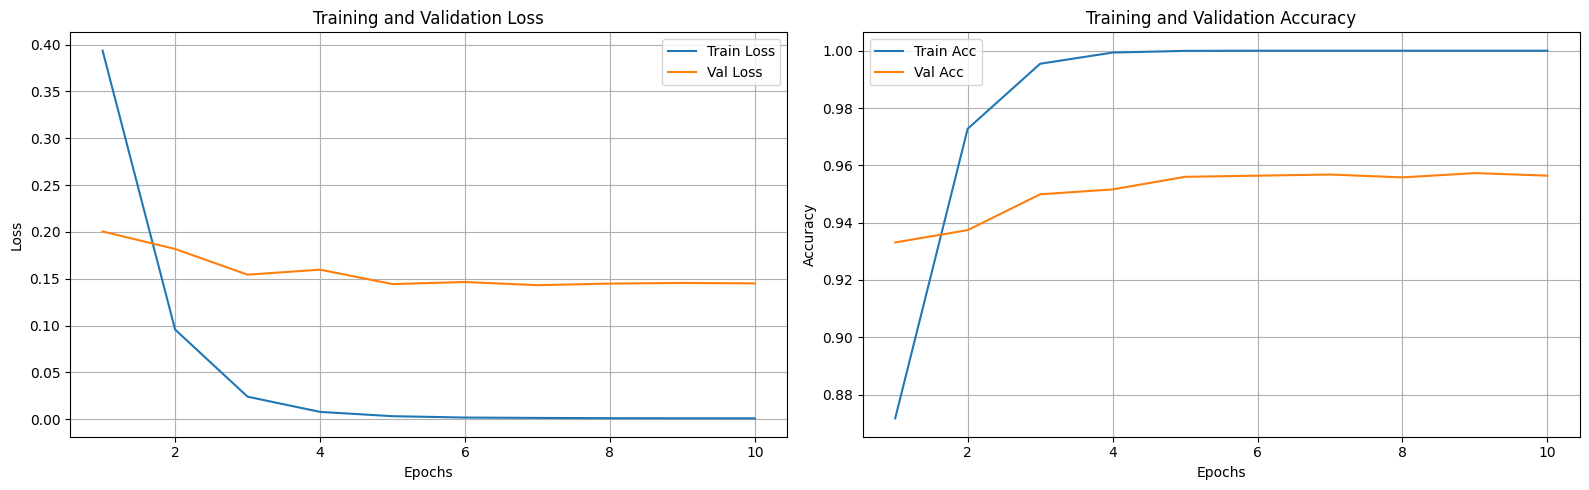

Loss: 0.1742618799686432
Acc: 0.9504


tensor([[-1.0521, -0.6305, -1.3319,  ..., -3.6249, -2.8880, -2.6435],
        [-0.3219, -0.4255, -0.9454,  ..., -1.4695, 13.9867, -3.5752],
        [-3.0169,  4.0242, -0.7693,  ..., -0.4408,  7.2013, -1.9212],
        ...,
        [-3.2909, -1.5822, -1.5674,  ..., -1.2239, -2.1068, -1.7704],
        [-1.4800,  7.4613,  2.1949,  ..., -1.9943, -1.8421, -2.2393],
        [-2.3338, -1.2871, -2.2489,  ..., 11.4630, -2.1699, -0.2537]],
       device='cuda:0')

In [ ]:
resnet18_e3 = models.resnet18(weights='DEFAULT')


for param in resnet18_e3.parameters():
    param.requires_grad = True



resnet18_e3.fc.requires_grad = True
num_ftrs = resnet18_e3.fc.in_features
resnet18_e3.fc = nn.Linear(num_ftrs, 10)

trainer = TrainerTorch(model=resnet18_e3, n_epochs=10, lr=0.0001, optimizer="Adam", cosine_learning_rate=True, regularization=True, lambda_reg=1e-4)

trainer.train(train_subset, val_subset)

trainer.predict(testset)

- Eksperyment 4 - Trening od zera

  * Załaduj ten sam model ResNet, ale **bez wag pretrenowanych**.
  * Wytrenuj go od zera na tym samym zbiorze danych.
  * Wystarczy kilka pierwszych epok - celem jest obserwacja przebiegu uczenia.

Rozpoczynam trening na: cuda
[0.0008181356214843422]
Epoch 1/5 | Train Loss: 1.4454 | Val Loss: 1.4916 | Val Acc: 0.4887
[0.000473606797749979]
Epoch 2/5 | Train Loss: 0.9591 | Val Loss: 0.9566 | Val Acc: 0.6580
[0.00018237254218789433]
Epoch 3/5 | Train Loss: 0.7103 | Val Loss: 0.7005 | Val Acc: 0.7509
[2.6393202250021048e-05]
Epoch 4/5 | Train Loss: 0.5065 | Val Loss: 0.5862 | Val Acc: 0.7945
[0.0]
Epoch 5/5 | Train Loss: 0.3374 | Val Loss: 0.4785 | Val Acc: 0.8337


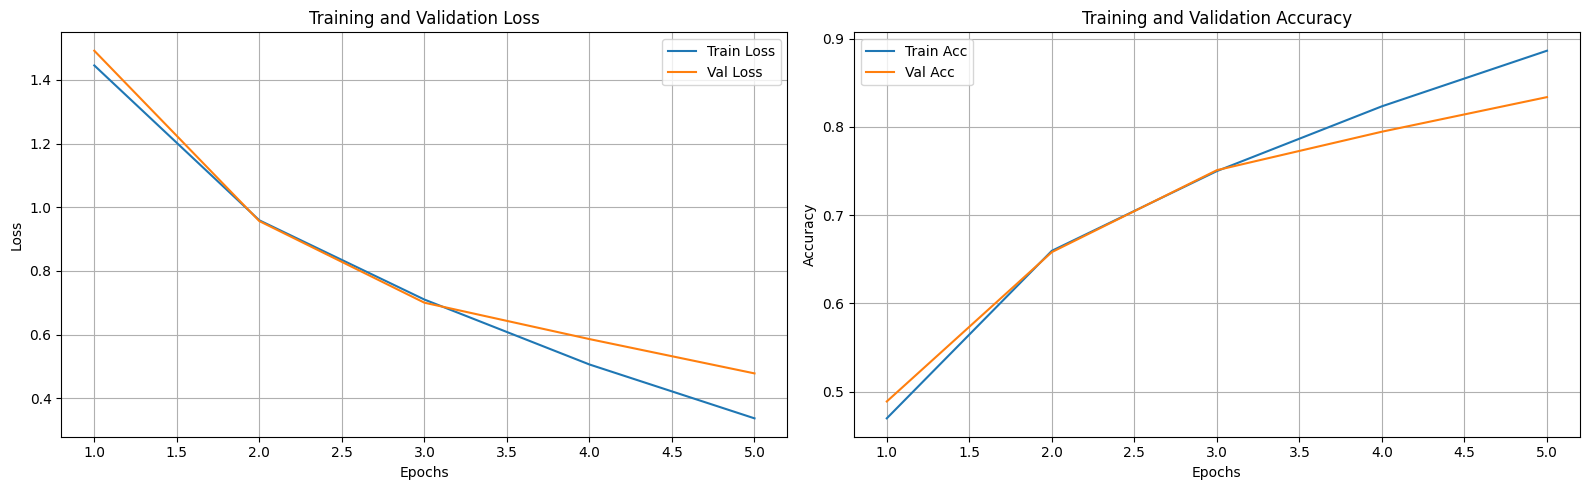

Loss: 0.4825188840389252
Acc: 0.8332


tensor([[-2.8389, -1.7527, -3.9697,  ..., -4.7229, -3.4529, -2.4346],
        [ 0.5749,  3.9087, -4.9041,  ..., -5.6369, 10.8885,  0.6929],
        [ 0.6903,  2.1562, -2.5824,  ..., -3.5579,  6.0133,  0.0230],
        ...,
        [-5.3527, -5.1396, -0.8364,  ...,  1.1740, -5.2078, -5.5930],
        [ 0.8627,  6.1691, -2.8480,  ..., -4.1495, -2.4135, -1.3384],
        [-4.2031, -2.5142, -1.7722,  ...,  9.6609, -7.3756, -5.0810]],
       device='cuda:0')

In [ ]:
resnet18_e4 = models.resnet18()


for param in resnet18_e4.parameters():
    param.requires_grad = True

resnet18_e4.fc.requires_grad = True
num_ftrs = resnet18_e4.fc.in_features
resnet18_e4.fc = nn.Linear(num_ftrs, 10)

trainer = TrainerTorch(model=resnet18_e4, n_epochs=5, lr=0.001, optimizer="Adam", cosine_learning_rate=True, regularization=True, lambda_reg=1e-4)

trainer.train(train_subset, val_subset)

trainer.predict(testset)

Jak widać w opcji 2 oraz 3 dokładność modelu była wysoka,co ciekawe val loss i training loss bardzo od siebie odbiegały, możliwe, że trzeba zmienić learning rate. Modele niestety robią overfitting.

Po puszczeniu od nowa widać, że modele się nauczyły lepiej gdy dałem więcej epok, full fine tuning wydaję się najlepszy, chociaż loss był dosyć liniowy